In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split

In [57]:
torch.manual_seed(42)

In [58]:
df=pd.read_csv("fmnist_small.csv")

In [59]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,125,72,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,3,0,2,0,0,210,228,228,233,0,0,0,0,0,0,0,0,0,31,81,133,184,201,190,117,0,0,2,1,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,43,117,34,15,24,33,117,80,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,51,144,152,...,157,158,161,148,159,58,0,6,0,0,0,0,0,0,0,0,0,4,0,60,143,143,148,146,152,152,148,148,147,145,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,0,0,0,2,0,33,114,37,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...,11,17,13,13,11,10,7,5,5,5,7,0,0,0,1,0,0,41,69,88,86,94,106,114,118,47,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,0,2,0,58,145,114,10,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,...,165,153,155,134,143,172,215,62,0,0,0,0,0,0,0,0,10,190,178,194,209,211,209,205,211,215,213,217,225,228,213,203,174,151,188,10,0,0,0,0


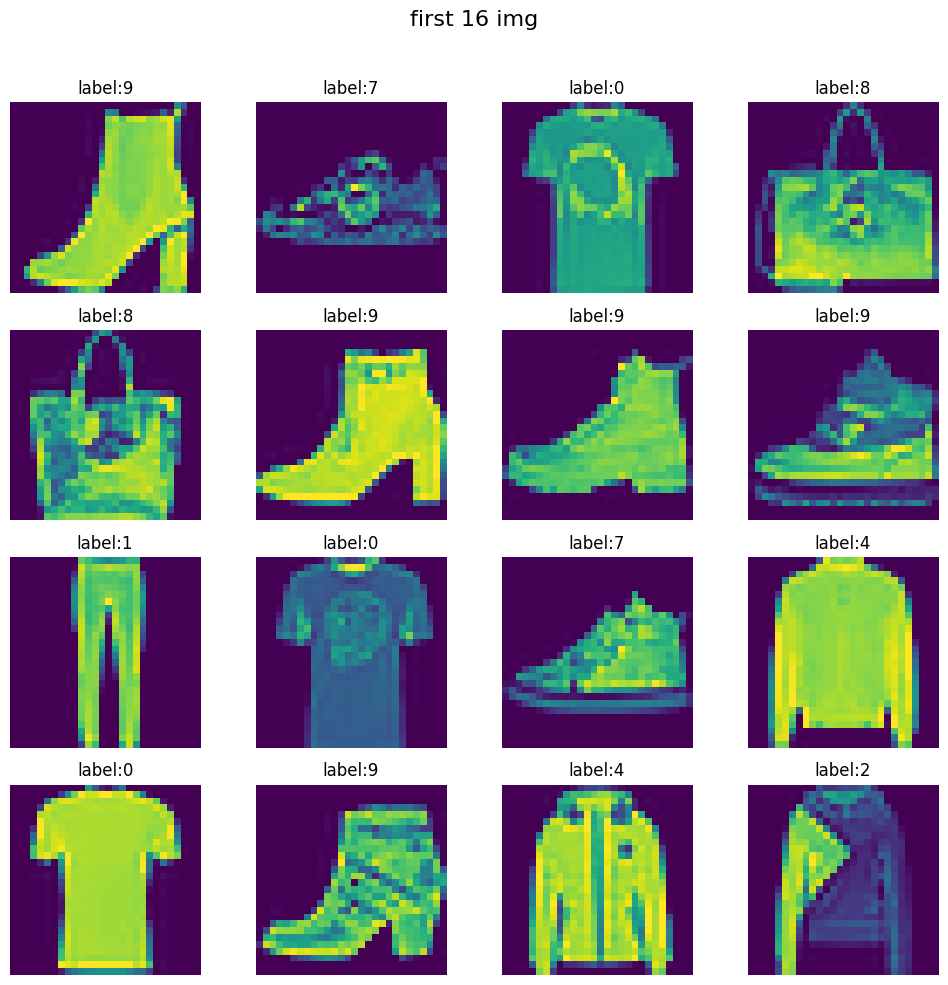

In [60]:
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("first 16 img",fontsize=16)

for i,ax in enumerate(axes.flat):
  img=df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"label:{df.iloc[i,0]}")
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [61]:
x=df.iloc[:,1:].values
y=df.iloc[:,0].values


In [62]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [63]:
X_train=X_train/255.0
X_test=X_test/255.0

In [64]:
X_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]])

In [65]:
from torch.utils.data import Dataset

class CustomDataset(Dataset):
  def __init__(self,features,label):
    self.features=torch.tensor(features,dtype=torch.float32)
    self.label=torch.tensor(label,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,idx):
    return self.features[idx],self.label[idx]

In [66]:
train_dataset=CustomDataset(X_train,y_train)
test_dataset=CustomDataset(X_test,y_test)

In [67]:
len(train_dataset)

4800

In [68]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [69]:
from  torch.utils.data import DataLoader
trainloader= DataLoader(train_dataset,batch_size=32,shuffle=True)
testloader= DataLoader(test_dataset,batch_size=32,shuffle=False)

In [70]:
from torch.nn.modules.module import Module
class MyNN(nn.Module):

  def __init__(self,num_features):
    super().__init__()
    self.model=nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )

  def forward(self,x):
    return self.model(x)

In [71]:
learning_rate=0.1
epochs=100

In [72]:
model=MyNN(num_features=X_train.shape[1])
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

In [73]:
for epoch in range(epochs):
  total_epoch_loss=0.0
  for batch_features,batch_labels in trainloader:
    y_pred=model(batch_features)
    loss=criterion(y_pred,batch_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epoch_loss+=loss.item()

  avgloss=total_epoch_loss/len(trainloader)
  print(f"epoch:{epoch+1},loss:{avgloss:.4f}")


epoch:1,loss:1.0507
epoch:2,loss:0.6295
epoch:3,loss:0.5425
epoch:4,loss:0.5042
epoch:5,loss:0.4389
epoch:6,loss:0.4075
epoch:7,loss:0.3788
epoch:8,loss:0.3598
epoch:9,loss:0.3393
epoch:10,loss:0.3139
epoch:11,loss:0.2912
epoch:12,loss:0.2886
epoch:13,loss:0.2650
epoch:14,loss:0.2532
epoch:15,loss:0.2406
epoch:16,loss:0.2399
epoch:17,loss:0.2089
epoch:18,loss:0.2082
epoch:19,loss:0.1949
epoch:20,loss:0.1917
epoch:21,loss:0.1837
epoch:22,loss:0.1698
epoch:23,loss:0.1726
epoch:24,loss:0.1582
epoch:25,loss:0.1526
epoch:26,loss:0.1387
epoch:27,loss:0.1382
epoch:28,loss:0.1348
epoch:29,loss:0.1265
epoch:30,loss:0.1212
epoch:31,loss:0.1158
epoch:32,loss:0.1085
epoch:33,loss:0.1070
epoch:34,loss:0.1049
epoch:35,loss:0.1108
epoch:36,loss:0.1100
epoch:37,loss:0.0950
epoch:38,loss:0.0853
epoch:39,loss:0.0712
epoch:40,loss:0.0906
epoch:41,loss:0.0831
epoch:42,loss:0.0716
epoch:43,loss:0.0627
epoch:44,loss:0.0566
epoch:45,loss:0.0591
epoch:46,loss:0.0536
epoch:47,loss:0.0476
epoch:48,loss:0.0848
e

In [74]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [75]:
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in testloader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

print(f"Accuracy = {100 * correct / total:.2f}%")

Accuracy = 84.50%
